# 머신러닝 심화 II — XGBoost · LightGBM · CatBoost 비교

**데이터**: Seaborn `titanic` (생존 이진 분류)

이 노트북은 Gradient Boosting 계열 3개 라이브러리를 비교합니다.

**학습 목표**
1. 세 모델의 **공통점 / 차별점** 이해
2. **방법 1**: scikit-learn API (`Pipeline` + `ColumnTransformer`, 결측치는 Pipeline에서 처리)
3. **방법 2**: **원래(native) API** (Pipeline 미사용, leakage-safe 전처리 + 라이브러리 자체 결측/범주 처리)
4. **Train / Val / Test** 분리 — Val은 early stopping·모델 선택, Test는 최종 평가만

> **Test 세트는 맨 마지막에 한 번만** 사용합니다.


## 1. 주요 내용 소개 — 공통점과 차별점

세 모델 모두 **Gradient Boosting Decision Tree (GBDT)** 계열입니다.

### 1-1. 공통점

| 항목 | 설명 |
|------|------|
| 알고리즘 골격 | Boosting (순차 앙상블) |
| 손실 최적화 | Gradient 기반 |
| 규제 | 트리 깊이, learning rate, subsample, L1/L2 등 |
| 실무 용도 | Kaggle / tabular 데이터에서 자주 상위권 |
| Early stopping | Val 세트로 부스팅 라운드를 조기 종료 가능 |

### 1-2. 차별점 (실무에서 체감되는 부분)

| 구분 | XGBoost | LightGBM | CatBoost |
|------|---------|----------|----------|
| 트리 성장 | Level-wise | **Leaf-wise** | Ordered / Oblivious tree |
| 범주형 처리 | 기본은 인코딩 필요 | 일부 native categorical 지원 | **강한 native categorical** |
| 결측치 | 자체 처리 가능 | 자체 처리 가능 | 자체 처리 가능 |
| sklearn API | `XGBClassifier` 등 | `LGBMClassifier` 등 | `CatBoostClassifier` 등 |
| Native 입력 | `numpy` / `DMatrix` | `numpy` / `Dataset` | `Pool` + `cat_features` |
| 특징 | 안정성 · 성숙한 생태계 | 대용량 · 속도 | 범주형 · overfitting 완화 옵션 |

### 1-3. 이 노트북의 두 가지 실습 방법

| | 방법 1 (sklearn API) | 방법 2 (원래 API) |
|--|----------------------|-------------------|
| Pipeline | 사용 | 보통 사용하지 않음 |
| ColumnTransformer | 사용 → **dense `numpy`** | 미사용 |
| 결측치 | `SimpleImputer` in Pipeline | train median 대치 또는 모델 자체 처리 |
| 범주형 | `OneHotEncoder` → 수치 행렬 | Ordinal(`numpy`) 또는 CatBoost `cat_features` |
| Leakage 방지 | `Pipeline.fit`은 train만 사용 | train 기준 통계만 fit → val/test transform |
| Early stopping | `eval_set=[(X_val, y_val)]` | 동일 개념, 입력 형식만 다름 |

### 1-4. Train / Val / Test 역할

| 세트 | 용도 |
|------|------|
| **Train** | 모델 학습, 전처리 fit |
| **Val** | early stopping, 과적합 모니터링 |
| **Test** | 최종 hold-out 평가 (한 번만) |


## 2. 환경 설정

In [1]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00


In [14]:
# 1. 시스템 제어 및 시간 측정 라이브러리 임포트
import warnings
import time

# 2. 데이터 처리 및 데이터 시각화 핵심 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. 사이킷런(Scikit-learn) 전처리 및 평가 모듈 임포트
import sklearn
from sklearn.compose import ColumnTransformer                     # 컬럼별로 독립된 전처리를 적용하는 변환기
from sklearn.impute import SimpleImputer                         # 결측치(NaN)를 특정 값으로 채우는 대치기
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score # 모델 평가용 3대 지표 (정확도, F1, ROC-AUC)
from sklearn.model_selection import train_test_split             # 데이터셋을 학습/테스트용으로 분할하는 모듈
from sklearn.pipeline import Pipeline                             # 전처리부터 모델까지 하나의 공정으로 묶어주는 파이프라인
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler # 인코딩 및 수치 스케일링 도구들

# 4. 고성능 그래디언트 부스팅(Gradient Boosting) 3대장 모델 임포트
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation # LightGBM 조기 종료 및 로그 출력 제어 콜백
from catboost import CatBoostClassifier, Pool                     # CatBoost 모델 및 전용 고성능 데이터 구조(Pool)

# 5. 실행 환경 설정 (경고 문구 제어 및 재현성 확보)
warnings.filterwarnings('ignore') # 코드 실행 시 발생하는 자잘한 경고(Warning) 메시지 숨기기
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)      # 넘파이 난수 시드를 고정하여 매번 실행할 때마다 동일한 결과가 나오도록 보장

# 6. 시각화(Matplotlib / Seaborn) 기본 스타일 및 폰트 설정
sns.set_theme(style='whitegrid')  # 깔끔하고 가독성 좋은 흰색 그리드 배경 스타일 적용
plt.rcParams.update({
    'figure.dpi': 110,            # 노트북 환경에서 차트가 선명하게 보이도록 해상도(DPI) 상향
    'axes.unicode_minus': False,  # 차트 축에 마이너스(-) 기호가 사각형으로 깨지는 현상 방지
})

# 7. 패키지 버전 출력 (개발 환경 동기화 및 디버깅용 제언)
print('sklearn :', sklearn.__version__)
print('xgboost :', __import__('xgboost').__version__)
print('lightgbm:', __import__('lightgbm').__version__)
print('catboost:', __import__('catboost').__version__)

sklearn : 1.6.1
xgboost : 3.3.0
lightgbm: 4.6.0
catboost: 1.2.10


## 3. 데이터 로드 · Train / Val / Test 분리 · 파생변수

**분리 먼저 → 각 세트에 파생변수 적용**합니다. 전처리 통계(median, encoder 등)는 **Train에서만 fit**합니다.


In [15]:
# 1. 시본(Seaborn) 내장 타이타닉 데이터셋 로드
titanic = sns.load_dataset('titanic')

# 2. 분석 및 모델 학습에 사용할 기본 피처(독립변수) 및 타깃 정의
base_features = [
    'pclass', 'age', 'sibsp', 'parch', 'fare',
    'sex', 'embarked', 'who', 'adult_male', 'alone',
]
target = 'survived'

# 3. 원본 데이터 보호를 위해 .copy()를 사용하여 독립변수(X)와 타깃(y) 분리
X = titanic.loc[:, base_features].copy()
y = titanic.loc[:, target].copy()


# 4. 데이터 누수(Data Leakage)를 방지하는 파생 변수 생성 함수 정의
def add_titanic_features(df):
    out = df.copy()
    # FamilySize: 동반 형제자매/배우자수 + 부모/자녀수 + 본인(1)
    out.loc[:, 'FamilySize'] = out.loc[:, 'sibsp'] + out.loc[:, 'parch'] + 1
    # IsAlone: 가족 수가 1명이면 혼자 탑승한 것으로 판단 (1: True, 0: False)
    out.loc[:, 'IsAlone'] = (out.loc[:, 'FamilySize'] == 1).astype(int)
    # FarePerPerson: 전체 티켓 요금을 가족 수로 나눈 1인당 요금
    out.loc[:, 'FarePerPerson'] = out.loc[:, 'fare'] / out.loc[:, 'FamilySize']
    return out


# =================================================================
# 5. Train / Validation / Test 3분할 홀드아웃(Hold-out) 수행
# =================================================================
# Step 1: 최종 평가용 Test 데이터셋 15%를 먼저 분리 (남은 데이터는 85%)
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y,
)

# Step 2: 남은 85% 데이터를 다시 분할하여 최종적으로 Train 70% / Val 15%가 되도록 조정
# val_ratio = 0.15 / 0.85 연산을 통해 전체 기준 정확히 15%에 해당하는 크기를 산출합니다.
val_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_ratio, random_state=RANDOM_STATE, stratify=y_tv,
)


# 6. 분할 완료된 3가지 데이터셋에 각각 파생 변수 함수 적용
X_train = add_titanic_features(X_train)
X_val = add_titanic_features(X_val)
X_test = add_titanic_features(X_test)


# 7. 불리언(True/False) 컬럼을 확실하게 64비트 정수형(np.int64)으로 변환
# 전처리 파이프라인 연산 과정에서 발생할 수 있는 데이터 타입 충돌을 방지합니다.
bool_cols = ['adult_male', 'alone']
for col in bool_cols:
    for df in (X_train, X_val, X_test):
        df[col] = df[col].astype(np.int64)


# 8. 향후 전처리를 위한 피처 목록 정립 및 범주형 변수 타입 정렬
numeric_features = [
    'pclass', 'age', 'sibsp', 'parch', 'fare',
    'FamilySize', 'IsAlone', 'FarePerPerson',
    'adult_male', 'alone',
]
categorical_features = ['sex', 'embarked', 'who']

# 범주형 컬럼은 문자열로 타입을 통일하여 인코더 연산 대비
for col in categorical_features:
    for df in (X_train, X_val, X_test):
        df.loc[:, col] = df.loc[:, col].astype(str)


# 9. 의도한 대로 데이터 크기(70% : 15% : 15%)와 타깃 분포(생존율)가 나뉘었는지 검증 출력
print('train:', X_train.shape, 'survived rate=', round(y_train.mean(), 3))
print('val  :', X_val.shape, 'survived rate=', round(y_val.mean(), 3))
print('test :', X_test.shape, 'survived rate=', round(y_test.mean(), 3))

# 최종 정제된 학습 데이터 상위 5개 행 확인
X_train.head()

train: (623, 13) survived rate= 0.384
val  : (134, 13) survived rate= 0.388
test : (134, 13) survived rate= 0.381


,pclass,age,sibsp,parch,fare,sex,embarked,who,adult_male,alone,FamilySize,IsAlone,FarePerPerson
632,1,32.0,0,0,30.500,male,C,man,1,1,1,1,30.5000
267,3,25.0,1,0,7.775,male,S,man,1,0,2,0,3.8875
482,3,50.0,0,0,8.050,male,S,man,1,1,1,1,8.0500
385,2,18.0,0,0,73.500,male,S,man,1,1,1,1,73.5000
405,2,34.0,1,0,21.000,male,S,man,1,0,2,0,10.5000


## 4. 공통 평가 · 시각화 유틸

Val / Test를 **동일 지표(ROC-AUC)** 로 비교합니다. 학습 곡선 제목은 **영어**로 표시합니다.


In [16]:
# 1. 하이퍼파라미터 상수 정의
# EARLY_STOPPING_ROUNDS: 검증 손실(Validation Loss)이 30회 연속으로 개선되지 않으면 학습을 자동 종료합니다.
# MAX_ESTIMATORS: 최대로 생성할 결정 트리의 개수(Boosting Round의 최대치)를 500개로 제한합니다.
EARLY_STOPPING_ROUNDS = 30
MAX_ESTIMATORS = 500


# 2. 최종 테스트 데이터셋 평가 함수 정의
# 모델과 테스트 데이터를 받아 3대 평가지표(정확도, F1, ROC-AUC)를 계산하여 반환합니다.
def evaluate_classifier(name, model, X_te, y_te, fit_time_sec):
    # 정답 클래스 예측값 (0 또는 1)
    y_pred = model.predict(X_te)

    # 1(생존)일 확률 예측값 (ROC-AUC 계산용)
    y_proba = model.predict_proba(X_te)[:, 1]

    return {
        'model': name,
        'fit_time_sec': fit_time_sec,
        'accuracy': accuracy_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'roc_auc': roc_auc_score(y_te, y_proba),
    }


# 3. 부스팅 학습 곡선(Learning Curve) 시각화 함수 정의
# 훈련 손실과 검증 손실이 라운드가 거듭됨에 따라 어떻게 감소하는지 꺾은선 그래프로 그립니다.
def plot_boosting_curves(curves, title, ax, ylabel='Log Loss'):
    """curves: {'Train': [...], 'Validation': [...]} 형태의 딕셔너리"""
    for label, values in curves.items():
        # 1라운드부터 데이터 길이만큼 X축을 설정하여 플롯 생성
        ax.plot(range(1, len(values) + 1), values, label=label, linewidth=2)
    ax.set_xlabel('Boosting Round')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


# 4. XGBoost 모델용 오차 이력 추출 함수 정의
def extract_xgb_curves(model, metric='logloss'):
    res = model.evals_result() # XGBoost 내부의 평가 스코어 기록 딕셔너리 추출

    # 사이킷런 API 기준 validation_0은 학습 데이터셋, validation_1은 검증 데이터셋을 의미합니다.
    train_key, val_key = 'validation_0', 'validation_1'
    return {
        'Train': res[train_key][metric],
        'Validation': res[val_key][metric],
    }


# 5. LightGBM 모델용 오차 이력 추출 함수 정의
def extract_lgbm_curves(model, metric='binary_logloss'):
    res = model.evals_result_ # LightGBM 내부의 평가 스코어 기록 딕셔너리 추출 (끝에 언더바 있음)
    keys = list(res.keys())   # 학습/검증 데이터셋의 세션 키 목록 가져오기

    # 두 개 이상의 데이터셋(Train, Validation)이 등록되어 있는 경우 대칭 구조 반환
    if len(keys) >= 2:
        return {
            'Train': res[keys[0]][metric],
            'Validation': res[keys[1]][metric],
        }
    # 검증 데이터셋만 기록되어 있을 경우의 예외 처리
    return {'Validation': res[keys[0]][metric]}


# 6. CatBoost 모델용 오차 이력 추출 함수 정의
def extract_catboost_curves(model, metric='Logloss'):
    res = model.get_evals_result() # CatBoost 내부의 평가 스코어 기록 딕셔너리 추출

    # CatBoost는 기본적으로 학습 데이터셋 기록을 'learn', 검증 데이터셋 기록을 'validation'으로 보관합니다.
    return {
        'Train': res['learn'][metric],
        'Validation': res['validation'][metric],
    }

---
# 방법 1. scikit-learn API 방식

- `Pipeline` + `ColumnTransformer` 구조를 **유지**합니다.
- 결측치 / 스케일링 / One-Hot은 **Pipeline 안에서** 처리합니다.
- Early stopping을 위해 **Preprocessor를 train에 fit**한 뒤, `numpy` 행렬로 변환해 `eval_set`에 넣습니다.


### 4-1. 공통 전처리 Pipeline

In [17]:
# 1. 수치형 변수(Numeric Features) 처리를 위한 파이프라인 정의
# 중앙값 대치 후 표준화 스케일링을 수행하는 연속적인 공정을 정의합니다.
numeric_transformer = Pipeline([
    # Step 1: 결측치(NaN)를 해당 컬럼의 '중앙값(median)'으로 채웁니다.
    ('imputer', SimpleImputer(strategy='median')),

    # Step 2: 평균을 0, 표준편차를 1로 만드는 표준화(StandardScaler)를 적용합니다.
    ('scaler', StandardScaler()),
])

# 2. 범주형 변수(Categorical Features) 처리를 위한 파이프라인 정의
# 최빈값 대치 후 원-핫 인코딩을 수행하는 연속적인 공정을 정의합니다.
categorical_transformer = Pipeline([
    # Step 1: 결측치(NaN)를 해당 컬럼에서 가장 빈도가 높은 '최빈값(most_frequent)'으로 채웁니다.
    ('imputer', SimpleImputer(strategy='most_frequent')),

    # Step 2: 원-핫 인코딩(One-Hot Encoding)을 통해 문자열 카테고리를 0과 1로 이루어진 여러 컬럼으로 확장합니다.
    # handle_unknown='ignore': 검증이나 테스트 데이터셋에서 처음 보는 범주가 나타나도 에러를 내지 않고 모두 0 처리합니다.
    # sparse_output=False: 희소 행렬이 아닌 조작이 용이한 일반 넘파이 배열(Dense Array) 형태로 결과를 반환합니다.
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# 3. 데이터 타입별로 변환기를 매핑하는 통합 전처리 객체(ColumnTransformer) 생성
# 데이터프레임이 들어오면 각 지정된 컬럼 리스트에 맞춰 전처리 파이프라인을 병렬로 적용합니다.
preprocessor = ColumnTransformer([
    # ('이름', 파이프라인객체, 대상피처리스트)
    ('num', numeric_transformer, numeric_features),       # 수치형 변수 영역 처리
    ('cat', categorical_transformer, categorical_features), # 범주형 변수 영역 처리
])

# 전처리 파이프라인 준비 완료 메시지 출력
print('sklearn API preprocessor ready')

sklearn API preprocessor ready


### 4-2. sklearn API — DataFrame → `numpy` 변환 확인

세 모델 모두 **동일한 dense `numpy` 행렬**을 받습니다. CatBoost sklearn API도 One-Hot 결과를 사용합니다 (방법 2와 대비).


In [18]:
# =================================================================
# 1) [Leakage-safe] 오직 Train 데이터셋으로만 기준 통계량 학습 (Fit)
# =================================================================
# 데이터 누수(Data Leakage)를 막기 위해 가장 중요한 단계입니다.
# 중앙값(median), 평균, 표준편차, 카테고리 종류 등 모든 전처리 기준은 오직 X_train만 보고 학습합니다.
preprocessor.fit(X_train)


# =================================================================
# 2) 학습된 규칙을 바탕으로 Train / Val / Test 데이터셋 일괄 변환 (Transform)
# =================================================================
# 검증(Val) 및 테스트(Test) 세트는 새로운 시험 문제이므로, 결코 새로운 통계량을 계산하지 않고
# 오직 X_train에서 얻어낸 전처리 규칙(중앙값, 스케일러 등)을 '그대로 적용'하여 채워 넣습니다.
X_train_sk = preprocessor.transform(X_train)
X_val_sk = preprocessor.transform(X_val)
X_test_sk = preprocessor.transform(X_test)


# =================================================================
# 3) 최종 변환된 데이터 매트릭스의 사양 및 샘플 데이터 출력 검증
# =================================================================
# ColumnTransformer를 거치면 판다스 데이터프레임이 아닌 사이킷런 내부 연산용 넘파이 배열(Numpy Array)로 출력됩니다.
print('sklearn API input type:', type(X_train_sk))

# 원-핫 인코딩(One-Hot Encoding)이 적용되면서 기존 13개였던 열(Columns)이 확장되어
# 전체 열의 개수가 늘어난 최종 매트릭스 형태(Shape)를 확인합니다.
print('train matrix shape:', X_train_sk.shape)
print('val matrix shape  :', X_val_sk.shape)
print('test matrix shape :', X_test_sk.shape)

# 모든 정수 및 문자열 데이터가 수치 연산에 최적화된 float64(실수형) 타입으로 일치되었는지 확인합니다.
print('dtype:', X_train_sk.dtype)

# 스케일링과 인코딩이 정상적으로 완료되어 데이터들이 압축된 수치 형태로 변환되었는지 첫 번째 행의 앞 8개 값만 샘플로 출력합니다.
print('sample row (first 8 values):', np.round(X_train_sk[0, :8], 3))

sklearn API input type: <class 'numpy.ndarray'>
train matrix shape: (623, 19)
val matrix shape  : (134, 19)
test matrix shape : (134, 19)
dtype: float64
sample row (first 8 values): [-1.574  0.139 -0.465 -0.461 -0.017 -0.548  0.8    0.287]


### 4-3. sklearn API — Early Stopping 학습 (Val 모니터링)

`n_estimators`를 크게 두고, Val 성능이 개선되지 않으면 조기 종료합니다.


In [19]:
import time
import pandas as pd

# 1. 사이킷런 호환 API 스타일의 부스팅 3대장 모델 생성 팩토리 정의
# 초기화 시점에 바로 모델 객체를 생성하지 않고, 루프 내에서 신선하게 인스턴스화하도록 람다(lambda) 함수 구조를 사용합니다.
sklearn_models_cfg = {
    'XGBoost (sklearn API)': lambda: XGBClassifier(
        n_estimators=MAX_ESTIMATORS,               # 최대 트리 개수 (500)
        max_depth=4,                               # 트리 최대 깊이
        learning_rate=0.05,                        # 학습률
        subsample=0.8,                             # 데이터 샘플링 비율
        colsample_bytree=0.8,                      # 피처 샘플링 비율
        reg_lambda=1.0,                            # L2 규제
        eval_metric='logloss',                     # 평가 지표
        early_stopping_rounds=EARLY_STOPPING_ROUNDS, # XGBoost는 생성자 내부에서 조기 종료 정의 가능
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'LightGBM (sklearn API)': lambda: LGBMClassifier(
        n_estimators=MAX_ESTIMATORS,
        max_depth=4,
        num_leaves=15,                             # 리프 노드 수 제한
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,                                # 로그 숨기기
    ),
    'CatBoost (sklearn API)': lambda: CatBoostClassifier(
        iterations=MAX_ESTIMATORS,                 # n_estimators와 동일 의미
        depth=4,                                   # max_depth와 동일 의미
        learning_rate=0.05,
        l2_leaf_reg=3.0,                           # reg_lambda와 동일 의미
        early_stopping_rounds=EARLY_STOPPING_ROUNDS, # CatBoost도 생성자 내부에서 정의 가능
        use_best_model=True,                       # 조기 종료 시 가장 성적이 좋았던 트리 시점 선택
        random_state=RANDOM_STATE,
        verbose=0,
        eval_metric='Logloss',
    ),
}

# 결과 저장용 컬렉션 초기화
sklearn_rows = []       # 요약 지표 행 저장 리스트
sklearn_fitted = {}     # 학습 완료된 모델 객체 보관용
sklearn_curves = {}     # 시각화용 학습 곡선 기록 보관용


# 2. 모델별 개별 최적화 및 평가 루프 수행
for name, factory in sklearn_models_cfg.items():
    model = factory() # 팩토리 함수를 호출하여 순수 모델 객체 생성
    t0 = time.perf_counter() # 학습 시간 측정 시작

    # [분기 1] LightGBM 전용 학습 및 조기 종료 프로세스
    if 'LightGBM' in name:
        model.fit(
            X_train_sk, y_train,
            eval_set=[(X_train_sk, y_train), (X_val_sk, y_val)], # 학습과 검증 오차를 모두 추적
            eval_metric='binary_logloss',
            callbacks=[
                # LightGBM은 fit 함수의 callbacks 인자를 통해 조기 종료와 로그 출력을 제어합니다.
                early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                log_evaluation(period=0), # 0으로 지정하여 중간 로그가 콘솔을 어지럽히지 않도록 차단
            ],
        )
        curves = extract_lgbm_curves(model) # 사전에 정의한 전용 추출 함수로 곡선 파싱

    # [분기 2] CatBoost 전용 학습 및 조기 종료 프로세스
    elif 'CatBoost' in name:
        model.fit(
            X_train_sk, y_train,
            eval_set=(X_val_sk, y_val), # 검증 세트를 투입하여 생성자에서 지정한 30라운드 룰 적용
        )
        curves = extract_catboost_curves(model)

    # [분기 3] XGBoost 및 기타 모델 전용 학습 프로세스
    else:
        model.fit(
            X_train_sk, y_train,
            eval_set=[(X_train_sk, y_train), (X_val_sk, y_val)],
            verbose=False,
        )
        curves = extract_xgb_curves(model)

    fit_time = time.perf_counter() - t0 # 학습 완료 후 소요 시간 계산

    # 딕셔너리에 영구 보관
    sklearn_fitted[name] = model
    sklearn_curves[name] = curves

    # 3. 사전 정의된 검증(Val) 세트와 테스트(Test) 세트를 사용해 다각도 지표 계산
    val_row = evaluate_classifier(name, model, X_val_sk, y_val, fit_time)
    test_row = evaluate_classifier(name, model, X_test_sk, y_test, fit_time)

    # 4. 리더보드 작성을 위한 지표 통합 딕셔너리 구성
    row = {
        'model': name,
        # getattr: 모델마다 조기 종료 후 최종 선택된 최적 트리 번호를 담고 있는 속성명(best_iteration_ 또는 best_iteration)이 다르므로 이를 안전하게 추출합니다.
        'best_iteration': getattr(model, 'best_iteration_', getattr(model, 'best_iteration', None)),
        'fit_time_sec': fit_time,
        'val_roc_auc': val_row['roc_auc'],
        'val_accuracy': val_row['accuracy'],
        'test_roc_auc': test_row['roc_auc'],
        'test_accuracy': test_row['accuracy'],
        'test_f1': test_row['f1'],
    }
    sklearn_rows.append(row)

    # 각 모델별 핵심 요약 스코어 실시간 출력
    print(
        f"{name:28s} | val AUC={row['val_roc_auc']:.4f} | "
        f"test AUC={row['test_roc_auc']:.4f} | rounds={row['best_iteration']} | fit={fit_time:.2f}s"
    )

# 5. 전체 행을 묶어 데이터프레임 리더보드로 빌드
# 최종 평가용 지표인 'test_roc_auc' 성적이 가장 뛰어난 순서대로 상단에 배치되도록 내림차순 정렬합니다.
sklearn_leaderboard = pd.DataFrame(sklearn_rows).sort_values('test_roc_auc', ascending=False)

# 소수점 4자리까지 반올림 포매팅하여 화면 출력
sklearn_leaderboard.round(4)

XGBoost (sklearn API)        | val AUC=0.9373 | test AUC=0.8065 | rounds=125 | fit=0.60s
LightGBM (sklearn API)       | val AUC=0.9333 | test AUC=0.7866 | rounds=191 | fit=0.19s
CatBoost (sklearn API)       | val AUC=0.9359 | test AUC=0.8291 | rounds=217 | fit=0.38s


,model,best_iteration,fit_time_sec,val_roc_auc,val_accuracy,test_roc_auc,test_accuracy,test_f1
2,CatBoost (sklearn API),217,0.3785,0.9359,0.8955,0.8291,0.7761,0.6939
0,XGBoost (sklearn API),125,0.5960,0.9373,0.8881,0.8065,0.7612,0.6800
1,LightGBM (sklearn API),191,0.1880,0.9333,0.8731,0.7866,0.7761,0.6939


### 4-4. sklearn API — Overfitting Curves (Train vs Validation)

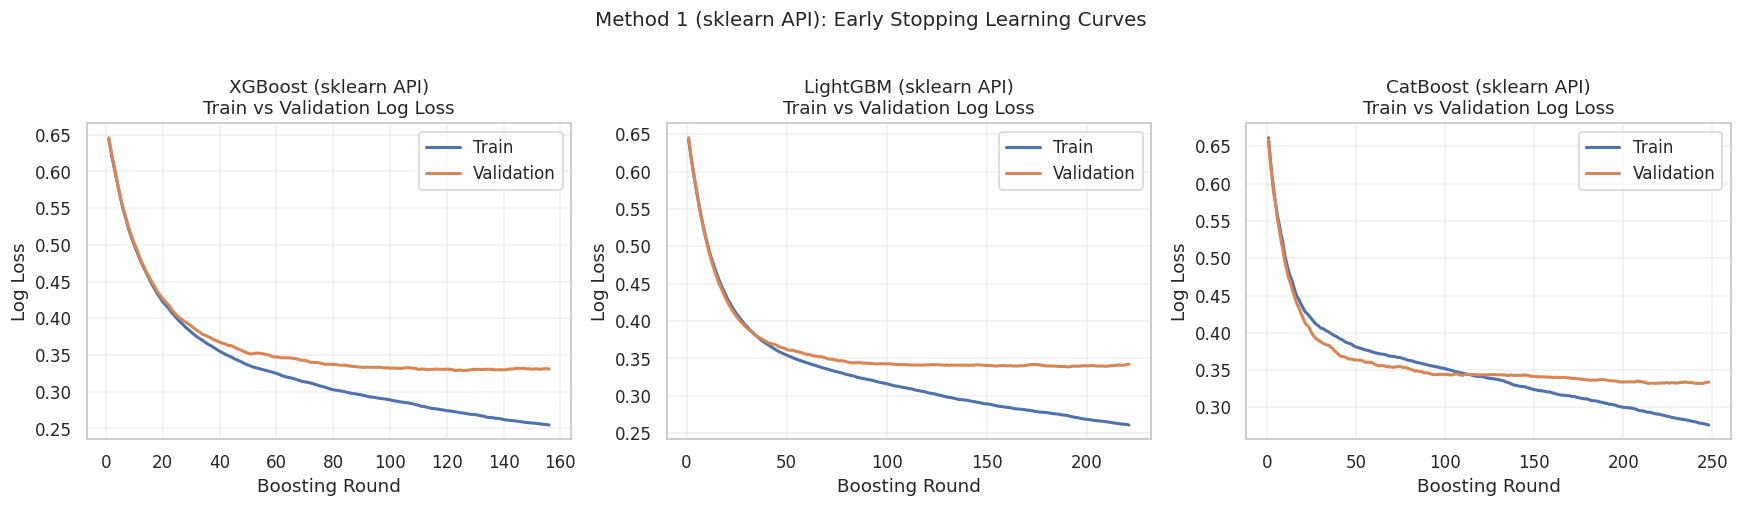

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, curves) in zip(axes, sklearn_curves.items()):
    plot_boosting_curves(
        curves,
        title=f'{name}\nTrain vs Validation Log Loss',
        ax=ax,
        ylabel='Log Loss',
    )
plt.suptitle('Method 1 (sklearn API): Early Stopping Learning Curves', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


---
# 방법 2. 원래(native) API 방식

- **Pipeline / ColumnTransformer를 사용하지 않습니다.**
- 대신 **Data Leakage를 막도록** 전처리를 직접 설계합니다.
  - 수치형 결측 대치: **train의 median만** 계산 → val/test에 적용
  - XGB/LGBM: Ordinal → **`numpy.float` 행렬**
  - CatBoost: 범주형 **문자열 유지** → **`Pool` + `cat_features`**


### 5-1. Leakage-safe 전처리 (train에만 fit)

| 모델 | 수치 결측 | 입력 형식 |
|------|-----------|-----------|
| XGBoost | train-median 대치 | `numpy.ndarray` (Ordinal) |
| LightGBM | train-median 대치 | `numpy.ndarray` (Ordinal) |
| CatBoost | train-median 대치 | `Pool` + `cat_features` (문자열 범주) |


In [20]:
import pandas as pd
import numpy as np
from catboost import Pool

# 1. 수치형 변수 기준값 학습 함수 (Train 기준)
def fit_numeric_medians(df, num_cols):
    # 데이터 누수를 방지하기 위해 오직 Train 데이터셋의 중앙값(Median)만 수집합니다.
    return df.loc[:, num_cols].median(numeric_only=True)

# 2. 수치형 변수 변환 및 결측치 대치 함수
def transform_numeric(df, num_cols, medians):
    out = df.copy()
    for col in num_cols:
        # 안전한 수치 연산을 위해 데이터를 숫자로 강제 형변환 (오류 값은 NaN 처리)
        out.loc[:, col] = pd.to_numeric(out.loc[:, col], errors='coerce')
        # 학습 단계에서 구해온 중앙값으로 결측치를 대치합니다.
        out.loc[:, col] = out.loc[:, col].fillna(medians[col])
    return out


# 3. 범주형 변수 인코더 학습 함수 (Train 기준)
def fit_ordinal_encoder(df, cat_cols):
    # 처음 보는 범주가 들어와도 에러를 내지 않고 -1로 맵핑하는 안전한 오디널 인코더 정의
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    enc.fit(df.loc[:, cat_cols].astype(str))
    return enc

# 4. 범주형 변수 정수 변환 함수
def transform_ordinal(df, cat_cols, enc):
    out = df.copy()
    # 문자열 범주를 정수 기반의 float 배열로 변환합니다.
    encoded = enc.transform(out.loc[:, cat_cols].astype(str))
    for i, col in enumerate(cat_cols):
        out[col] = encoded[:, i].astype(float)
    return out


# 5. CatBoost 전용 범주형 결측치 텍스트화 함수 정의
def prepare_catboost_frame(df, cat_cols):
    out = df.copy()
    for col in cat_cols:
        # 판다스 내부의 다양한 결측 표현식(NaN, None, 이형 문자열 nan 등)을
        # CatBoost가 하나의 유효한 문자열 카테고리로 인식하도록 'missing' 단어로 통일합니다.
        out[col] = (
            out[col]
            .astype(object)
            .fillna('missing')
            .astype(str)
            .replace({'nan': 'missing', 'None': 'missing', 'NaN': 'missing'})
        )
    return out


# =================================================================
# 6. [Leakage-safe] 전처리 핏(Fit) 단계는 철저하게 Train 데이터로만 수행
# =================================================================
num_medians = fit_numeric_medians(X_train, numeric_features)
ord_encoder = fit_ordinal_encoder(X_train, categorical_features)


# =================================================================
# 7. XGBoost / LightGBM용 입력 데이터셋 매트릭스 생성 (Numpy 2D Array)
# =================================================================
# 수치 대치와 오디널 인코딩을 순차적으로 수행한 뒤, 모델 연산 최적화를 위해
# 최종적으로 전부 float 타입의 넘파이 배열(Numpy Array)로 내보내는 헬퍼 함수를 정의합니다.
def to_xgb_lgbm_matrix(df):
    out = transform_ordinal(
        transform_numeric(df, numeric_features, num_medians),
        categorical_features,
        ord_encoder,
    )
    return out.astype(float).to_numpy()

# Train, Val, Test 세트를 각각 넘파이 매트릭스로 완벽 변환
X_train_np = to_xgb_lgbm_matrix(X_train)
X_val_np = to_xgb_lgbm_matrix(X_val)
X_test_np = to_xgb_lgbm_matrix(X_test)


# =================================================================
# 8. CatBoost용 입력 데이터셋 및 전용 Pool 객체 생성
# =================================================================
# CatBoost는 수치형만 중앙값으로 대치하고, 범주형은 숫자로 바꾸지 않은 채
# 'missing', 'male' 같은 텍스트 원본 상태를 유지하여 데이터프레임을 생성합니다.
X_train_cb = prepare_catboost_frame(
    transform_numeric(X_train, numeric_features, num_medians), categorical_features,
)
X_val_cb = prepare_catboost_frame(
    transform_numeric(X_val, numeric_features, num_medians), categorical_features,
)
X_test_cb = prepare_catboost_frame(
    transform_numeric(X_test, numeric_features, num_medians), categorical_features,
)

# CatBoost 내부에서 텍스트 기반 카테고리 특화 연산을 수행할 수 있도록 cat_features 옵션을 지정해 Pool 객체 구축
cat_feature_names = list(categorical_features)
train_pool = Pool(X_train_cb, y_train, cat_features=cat_feature_names)
val_pool = Pool(X_val_cb, y_val, cat_features=cat_feature_names)
test_pool = Pool(X_test_cb, y_test, cat_features=cat_feature_names)


# =================================================================
# 9. 최종 변환 결과 사양 검증 출력
# =================================================================
# XGB/LGBM용 데이터가 깔끔한 넘파이 float64 배열로 빌드되었는지 확인
print('XGB/LGBM input:', type(X_train_np), X_train_np.shape, X_train_np.dtype)

# CatBoost용 범주형 피처들이 인코딩되지 않고 문자열 단어로 잘 살아있는지 상위 3개 행 예시 확인
print('CatBoost input: pandas DataFrame + Pool')
print('CatBoost categorical sample:')
print(X_train_cb.loc[:, categorical_features].head(3))

XGB/LGBM input: <class 'numpy.ndarray'> (623, 13) float64
CatBoost input: pandas DataFrame + Pool
CatBoost categorical sample:
      sex embarked  who
632  male        C  man
267  male        S  man
482  male        S  man


### 5-2. Native API — Early Stopping 학습

각 라이브러리의 **고유 문법**으로 `eval_set` / `Pool` / callback을 사용합니다.


In [21]:
import time
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# 결과 저장용 컬렉션 초기화
native_rows = []       # 요약 지표 행 저장 리스트
native_fitted = {}     # 학습 완료된 모델 객체 보관용
native_curves = {}     # 시각화용 학습 곡선 기록 보관용

# =================================================================
# 1. XGBoost Native-Style 학습 및 평가
# =================================================================
xgb_native = XGBClassifier(
    n_estimators=MAX_ESTIMATORS,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric='logloss',
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
t0 = time.perf_counter() # 학습 시간 측정 시작
# 오디널 인코딩과 수치 대치가 완료된 넘파이 배열(X_train_np) 주입
xgb_native.fit(
    X_train_np, y_train,
    eval_set=[(X_train_np, y_train), (X_val_np, y_val)],
    verbose=False,
)
xgb_time = time.perf_counter() - t0 # 학습 소요 시간 계산

# 모델 및 학습 곡선 기록 저장
native_fitted['XGBoost (native API)'] = xgb_native
native_curves['XGBoost (native API)'] = extract_xgb_curves(xgb_native)

# 검증 및 테스트 데이터셋 성능 지표 산출
xgb_val = evaluate_classifier('XGBoost (native API)', xgb_native, X_val_np, y_val, xgb_time)
xgb_test = evaluate_classifier('XGBoost (native API)', xgb_native, X_test_np, y_test, xgb_time)

# 리더보드용 데이터 축적
native_rows.append({
    'model': 'XGBoost (native API)',
    'best_iteration': xgb_native.best_iteration, # 최적의 트리 개수 라운드 번호
    'fit_time_sec': xgb_time,
    'val_roc_auc': xgb_val['roc_auc'],
    'test_roc_auc': xgb_test['roc_auc'],
    'test_accuracy': xgb_test['accuracy'],
    'test_f1': xgb_test['f1'],
})
print(f"XGBoost native | val AUC={xgb_val['roc_auc']:.4f} | test AUC={xgb_test['roc_auc']:.4f}")


# =================================================================
# 2. LightGBM Native-Style 학습 및 평가
# =================================================================
lgbm_native = LGBMClassifier(
    n_estimators=MAX_ESTIMATORS,
    max_depth=4,
    num_leaves=15,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
t0 = time.perf_counter()
# 오디널 인코딩과 수치 대치가 완료된 넘파이 배열(X_train_np) 주입
lgbm_native.fit(
    X_train_np, y_train,
    eval_set=[(X_train_np, y_train), (X_val_np, y_val)],
    eval_metric='binary_logloss',
    callbacks=[
        early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
        log_evaluation(period=0),
    ],
)
lgbm_time = time.perf_counter() - t0

native_fitted['LightGBM (native API)'] = lgbm_native
native_curves['LightGBM (native API)'] = extract_lgbm_curves(lgbm_native)

lgbm_val = evaluate_classifier('LightGBM (native API)', lgbm_native, X_val_np, y_val, lgbm_time)
lgbm_test = evaluate_classifier('LightGBM (native API)', lgbm_native, X_test_np, y_test, lgbm_time)

native_rows.append({
    'model': 'LightGBM (native API)',
    'best_iteration': lgbm_native.best_iteration_, # 사이킷런 API 형태이므로 끝에 언더바(_) 포함
    'fit_time_sec': lgbm_time,
    'val_roc_auc': lgbm_val['roc_auc'],
    'test_roc_auc': lgbm_test['roc_auc'],
    'test_accuracy': lgbm_test['accuracy'],
    'test_f1': lgbm_test['f1'],
})
print(f"LightGBM native | val AUC={lgbm_val['roc_auc']:.4f} | test AUC={lgbm_test['roc_auc']:.4f}")


# =================================================================
# 3. CatBoost Native-Style 학습 및 평가
# =================================================================
cb_native = CatBoostClassifier(
    iterations=MAX_ESTIMATORS,
    depth=4,
    learning_rate=0.05,
    l2_leaf_reg=3.0,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    use_best_model=True,
    random_state=RANDOM_STATE,
    verbose=0,
    eval_metric='Logloss',
)
t0 = time.perf_counter()
# 넘파이 배열 대신 텍스트 카테고리가 온전히 살아있는 전용 Pool 객체 주입
cb_native.fit(train_pool, eval_set=val_pool)
cb_time = time.perf_counter() - t0

native_fitted['CatBoost (native API)'] = cb_native
native_curves['CatBoost (native API)'] = extract_catboost_curves(cb_native)

# Pool 구조 특성상 전용 predict_proba 메서드를 사용해 예측 확률 직접 산출
cb_val_proba = cb_native.predict_proba(val_pool)[:, 1]
cb_test_proba = cb_native.predict_proba(test_pool)[:, 1]
cb_val_auc = roc_auc_score(y_val, cb_val_proba)
cb_test_auc = roc_auc_score(y_test, cb_test_proba)

native_rows.append({
    'model': 'CatBoost (native API)',
    'best_iteration': cb_native.get_best_iteration(), # CatBoost 전용 메서드로 최적 라운드 수 추출
    'fit_time_sec': cb_time,
    'val_roc_auc': cb_val_auc,
    'test_roc_auc': cb_test_auc,
    'test_accuracy': accuracy_score(y_test, cb_native.predict(test_pool)),
    'test_f1': f1_score(y_test, cb_native.predict(test_pool)),
})
print(f"CatBoost native | val AUC={cb_val_auc:.4f} | test AUC={cb_test_auc:.4f}")


# =================================================================
# 4. 종합 Native 리더보드 데이터프레임 빌드
# =================================================================
# 최종 테스트 데이터셋 성능(test_roc_auc)을 기준으로 내림차순 정렬하여 최종 순위 테이블 마감
native_leaderboard = pd.DataFrame(native_rows).sort_values('test_roc_auc', ascending=False)
native_leaderboard.round(4)

XGBoost native | val AUC=0.9323 | test AUC=0.8110
LightGBM native | val AUC=0.9295 | test AUC=0.8068
CatBoost native | val AUC=0.9349 | test AUC=0.8283


,model,best_iteration,fit_time_sec,val_roc_auc,test_roc_auc,test_accuracy,test_f1
2,CatBoost (native API),271,2.6880,0.9349,0.8283,0.7612,0.6735
0,XGBoost (native API),90,1.2931,0.9323,0.8110,0.7537,0.6598
1,LightGBM (native API),93,0.4322,0.9295,0.8068,0.7836,0.7010


### 5-3. Native API — Overfitting Curves (Train vs Validation)

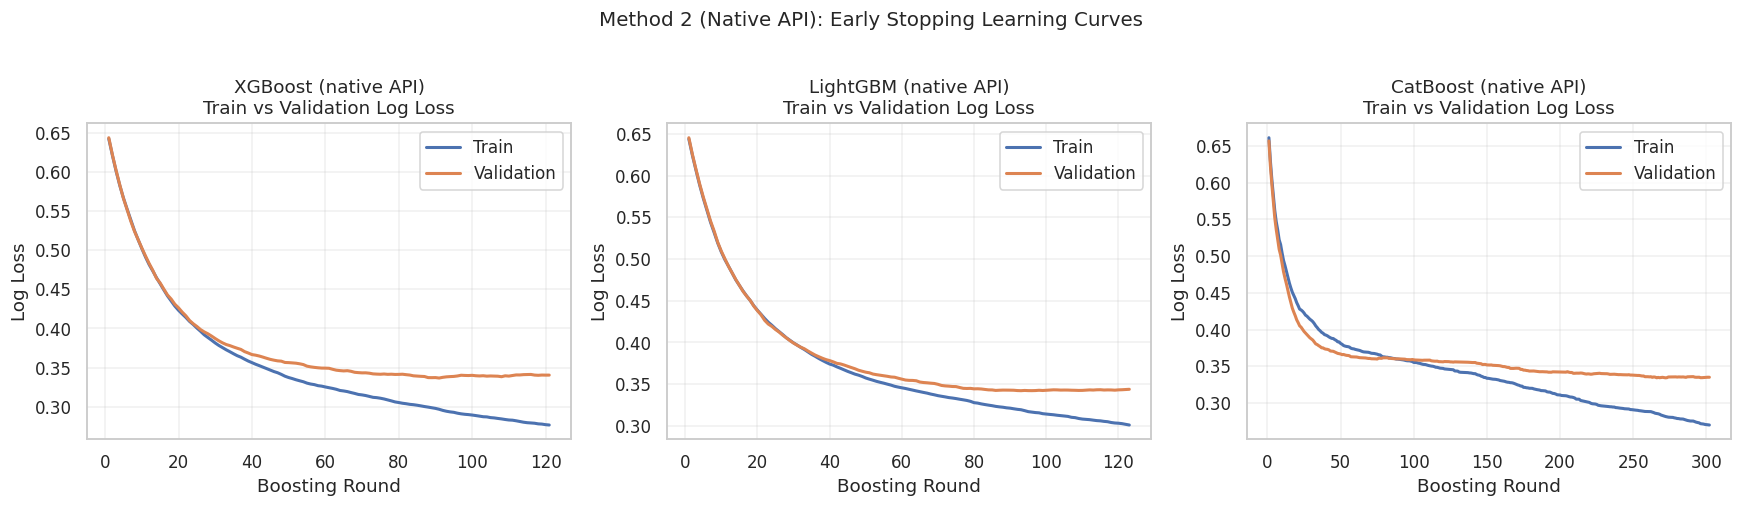

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, curves) in zip(axes, native_curves.items()):
    plot_boosting_curves(
        curves,
        title=f'{name}\nTrain vs Validation Log Loss',
        ax=ax,
        ylabel='Log Loss',
    )
plt.suptitle('Method 2 (Native API): Early Stopping Learning Curves', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 6. 방법 1 vs 방법 2 종합 비교

Val AUC는 모델 선택·early stopping 참고용, **Test AUC가 최종 hold-out 성능**입니다.


In [12]:
sklearn_lb = sklearn_leaderboard.copy()
sklearn_lb['method'] = 'sklearn API'
native_lb = native_leaderboard.copy()
native_lb['method'] = 'native API'

combined = pd.concat([sklearn_lb, native_lb], ignore_index=True)
combined = combined.sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
combined.loc[:, [
    'method', 'model', 'best_iteration', 'val_roc_auc',
    'test_roc_auc', 'test_accuracy', 'test_f1', 'fit_time_sec',
]].round(4)


,method,model,best_iteration,val_roc_auc,test_roc_auc,test_accuracy,test_f1,fit_time_sec
0,sklearn API,CatBoost (sklearn API),217,0.9359,0.8291,0.7761,0.6939,0.2985
1,native API,CatBoost (native API),271,0.9349,0.8283,0.7612,0.6735,0.7704
2,native API,XGBoost (native API),90,0.9323,0.8110,0.7537,0.6598,0.0741
3,native API,LightGBM (native API),93,0.9295,0.8068,0.7836,0.7010,0.0379
4,sklearn API,XGBoost (sklearn API),125,0.9373,0.8065,0.7612,0.6800,0.1848
5,sklearn API,LightGBM (sklearn API),191,0.9333,0.7866,0.7761,0.6939,0.1580


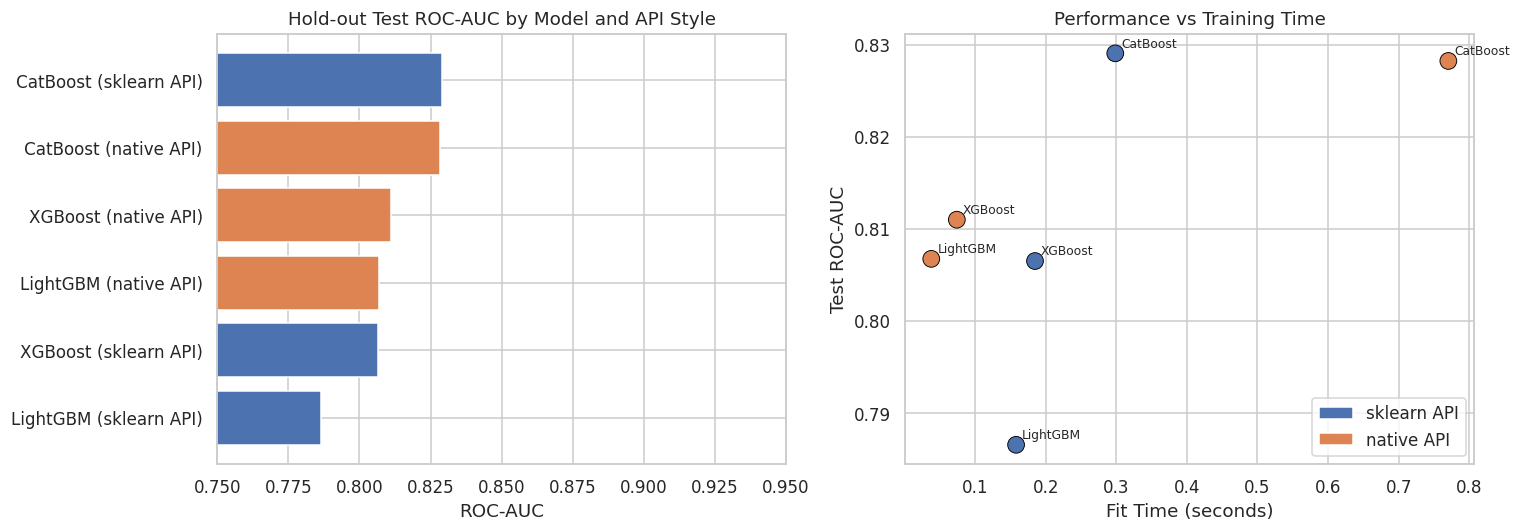

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = combined.sort_values('test_roc_auc', ascending=True)
colors = ['#4C72B0' if m == 'sklearn API' else '#DD8452' for m in plot_df['method']]

axes[0].barh(plot_df['model'], plot_df['test_roc_auc'], color=colors)
axes[0].set_xlabel('ROC-AUC')
axes[0].set_title('Hold-out Test ROC-AUC by Model and API Style')
axes[0].set_xlim(0.75, 0.95)

axes[1].scatter(
    combined['fit_time_sec'],
    combined['test_roc_auc'],
    c=combined['method'].map({'sklearn API': '#4C72B0', 'native API': '#DD8452'}),
    s=120,
    edgecolors='black',
    linewidths=0.6,
)
for _, r in combined.iterrows():
    axes[1].annotate(
        r['model'].split(' ')[0],
        (r['fit_time_sec'], r['test_roc_auc']),
        textcoords='offset points',
        xytext=(4, 4),
        fontsize=8,
    )
axes[1].set_xlabel('Fit Time (seconds)')
axes[1].set_ylabel('Test ROC-AUC')
axes[1].set_title('Performance vs Training Time')

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='#4C72B0', label='sklearn API'),
    Patch(facecolor='#DD8452', label='native API'),
], loc='lower right')

plt.tight_layout()
plt.show()


## 7. 정리 — 언제 어떤 방식을 쓸까?

### 방법 1 (sklearn API)을 쓰면 좋을 때
- `GridSearchCV`, `Pipeline`, `ColumnTransformer` 등 **sklearn 생태계와 통합**이 필요할 때
- 전처리와 모델을 **한 객체로 묶어** CV / 저장 / 배포를 단순화하고 싶을 때
- 팀 내 표준 파이프라인이 sklearn 중심일 때

### 방법 2 (native API)을 쓰면 좋을 때
- `Pool`, `DMatrix`, `Dataset` 등 **라이브러리 고유 기능**이 필요할 때
- CatBoost `cat_features`처럼 **범주형을 One-Hot 없이** 넣고 싶을 때
- early stopping, custom metric, GPU 옵션 등을 **세밀하게 제어**할 때

### Data Leakage 체크리스트
- [ ] Train / Val / Test 분리 후, **파생변수·전처리 fit은 Train만** 사용했는가?
- [ ] Val은 early stopping·모델 선택에만 사용하고, Test는 **최종 1회** 평가했는가?
- [ ] Test 성능으로 하이퍼파라미터를 다시 조정하지 않았는가?
- [ ] Native 방식에서 median / encoder / `cat_features` 규칙이 **Train 기준**인가?
